- Implement/use SIFT
- Match keypoints between image pairs
- Draw match visualization

SIFT (Scale-Invariant Feature Transform) is a feature extraction algorithm used in computer vision to detect and describe important local patterns in an image.

SIFT detects distinctive points in an image (keypoints) and encodes each point with a feature vector (descriptor) that describes its local visual pattern, allowing robust comparison between images.

In [1]:
from pathlib import Path
import sys

# BASE_DIR = Path(__file__).resolve().parent
BASE_DIR = Path().resolve().parent

sys.path.append(str(BASE_DIR))

train_path = BASE_DIR / "data" / "raw" / "Training"
test_path = BASE_DIR / "data" / "raw" / "Testing"

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from modules.data_loader import load_data
from modules.preprocessing import standardize

X_train, y_train = load_data(train_path)
X_test, y_test = load_data(test_path)

# Apply preprocessing to the loaded data
X_train = [standardize(img) for img in X_train]
X_test = [standardize(img) for img in X_test]

In [3]:
from modules.sift import get_sift_features
from modules.sift import match_images, matching_accuracy, average_matching_score

In [60]:
img1 = X_train[45]
img2 = X_train[500]

# match two images using their SIFT features
matched_img, matches = match_images(img1, img2)

score = matching_accuracy(matches)

print("SIFT Matching Score:", score)

y_train = np.array(y_train)

# 40 35 = 78
# 45 55 = 80
# 45 500 85


SIFT Matching Score: 0.717458357591485


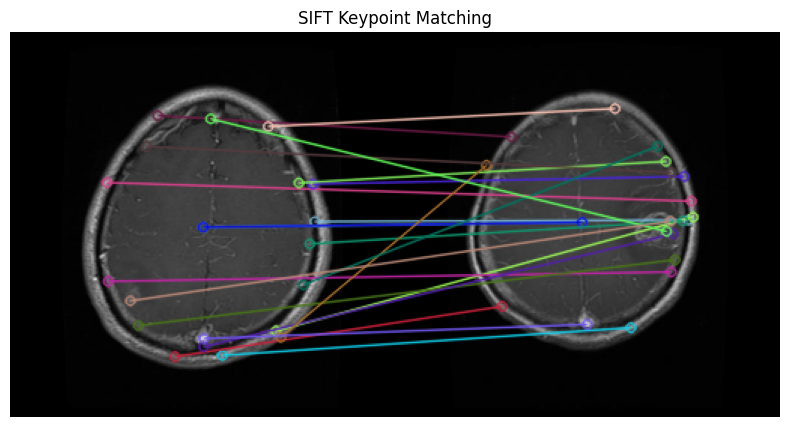

In [61]:
plt.figure(figsize=(10,5))
plt.imshow(matched_img)
plt.axis("off")
plt.title("SIFT Keypoint Matching")
plt.show()